### Segment Anything Model (SAM)

SAM employs computer vision to simplify image segmentation (https://arxiv.org/abs/2304.02643). 

In this notebook, we use the [segment-geospatial package](https://samgeo.gishub.org) to utilize SAM for geospatial segmentation. 

We use a SamGeo model to segment an orthoimgage from Rovaniemi, Finland. As a result, the model produces:
* A georeferenced segmentation mask of all objects it can detect
* The objects also in vector format. 

SamGeo works in two modes, which both have their limitations:
* Default mode: Feed the input image to SAM, rescaling it to suitable size.
    * This gives segmented raster, where each object has its own value. But the result is limited to have 255 different values, so only 255 segmented objects.  
* Batch mode: Tile the input image to smaller tiles, and let SAM segment the tiles. This enables using the input data at full scale and give more detailed results.
    * This gives a binary raster, where all segmented objects have one value and background another. If segmented objects are next to each other, it becomes difficult to separate them at the vectorization step.

SAM is sensitive to pixel size. The smaller the pixels, the smaller objects SAM recognizes. Selecting suitable pixel size, can help to recognize objects of intended size. 

SamGeo supports several models, also SAM2 and SAM3. For example it is possible to detetect objects also using a text prompt. See [SamGeo Examples](https://samgeo.gishub.org/examples/text_prompts/). 

Note, that SamGEO [benefits from GPU availability](https://samgeo.gishub.org/#computing-resources).

Used data:
* [NLS Finland, Orthoimage](http://urn.fi/urn:nbn:fi:csc-kata00001000000000000198), downloaded from [Paituli](https://paituli.csc.fi). 

Steps in this notebook:
* Fetch input data image.
* Create SamGeo model, inc download pre-trained SAM model
* Generate object detections.
* Plot detected objects
* Convert detected objects to vector format.

In [1]:
import os 

# Plotting
import matplotlib.pyplot as plt

# Rasterio for getting image data
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show

# Samgeo
import samgeo
from samgeo import SamGeo
from samgeo.text_sam import LangSAM

# Vector data
import geopandas

To use SamGeo 2, install it as:
	pip install segment-geospatial[samgeo2]


Set paths and some settings.

In [2]:
base_folder = os.path.join(os.sep, 'scratch', 'project_462001167', 'students', os.environ.get('USER'), 'GeoML')
exercise_folder = os.path.join(base_folder, '07_segment_anything') 

# Files created in the exercise
image_path = os.path.join(exercise_folder, 'image.tif') 
segmented_image = os.path.join(exercise_folder, 'segment.tif')
annotated_image = os.path.join(exercise_folder, "annotations.tif")
polygons_file = os.path.join(exercise_folder, "polygons.gpkg")

# SAM-model
samgeo_model = 'vit_b' 

In [3]:
# Virtual raster of Finnish orthoimage from Paituli  
# This covers whole Finland
vrt_path = "https://www.nic.funet.fi/index/geodata/mml/orto/normal_color_3067/orto_newest.vrt"

# Use https://kartta.paikkatietoikkuna.fi/ with XY tool to select other point, use in order: E, N.
# Here we have selected coordinates from the centre of Rovaniemi, Finland
center_x, center_y = 445885, 7378186
# Create a bounding box around the chosen points
buffer_size = 200
xmin, ymin, xmax, ymax = center_x - buffer_size, center_y - buffer_size, center_x + buffer_size, center_y + buffer_size

Create raster image using the bounds from the orthoimage virtual raster.

In [4]:
with rasterio.open(vrt_path) as src:
    window=from_bounds(xmin, ymin, xmax, ymax, src.transform)
    vrt = src.read(window=window)
    profile = src.profile
    profile.update({
        "driver": 'GTiff',
        "width": vrt.shape[1],
        "height": vrt.shape[2],
        "transform": src.window_transform(window)
    })
    with rasterio.open(image_path, 'w', **profile) as i:
        i.write(vrt)

Show the created raster imagery

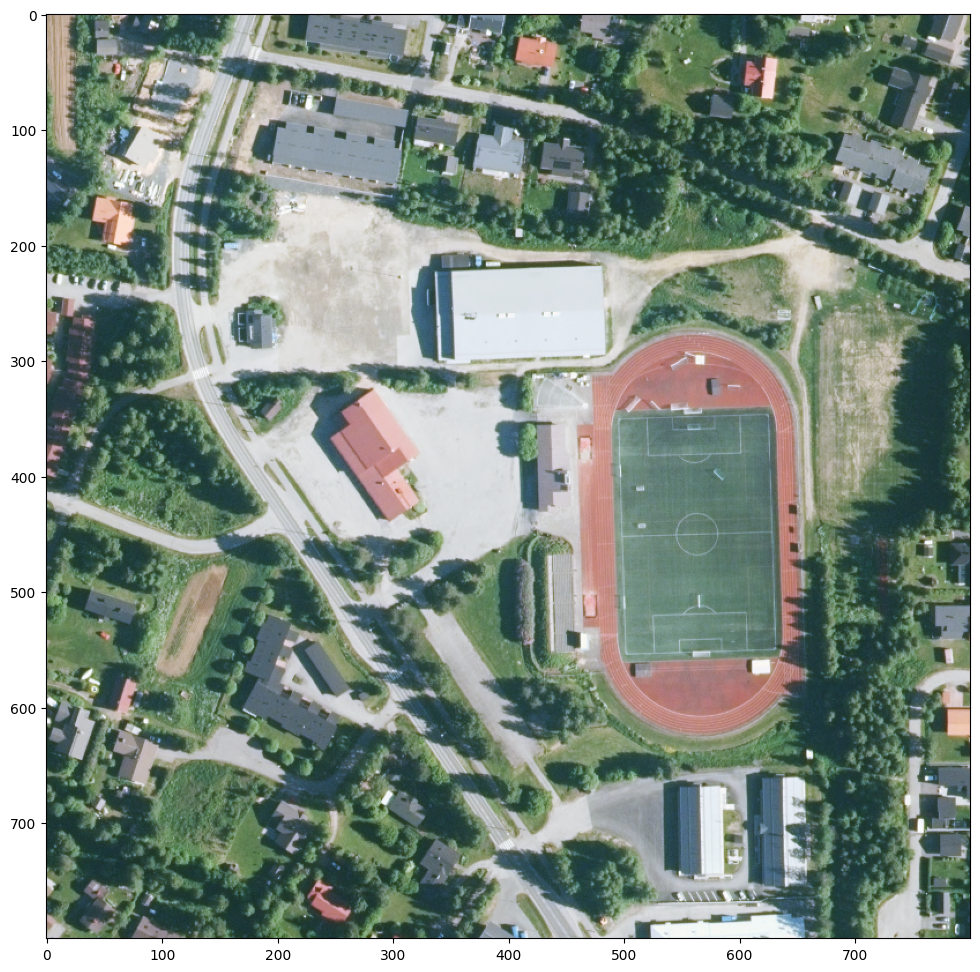

In [5]:
plt.figure(figsize=(12, 12))  # width, height in inches
show(vrt)
plt.show()

Load SamGeo model. This automatically loads pre-trained weigths for the model. 
* `model_type` - In the exercise we use ViT-B SAM model (basic), which is the smallest model in the [ViT-family](https://github.com/facebookresearch/segment-anything#model-checkpoints). It is fastest and requires least resourcs, but gives weakest results. For better quality, use ViT-H SAM model (huge). SamGeo has also newer version [SamGeo2](https://samgeo.gishub.org/samgeo2/), which provides additional models. See other options from [Samgeo documentation](https://github.com/facebookresearch/segment-anything#model-checkpoints)
* `checkpoint_dir` - where to store the model locally

In [6]:
sam = SamGeo(
    model_type=samgeo_model,
    checkpoint_dir=exercise_folder
)

Generate segmentation mask for the image and save it as GeoTiff. The created image is georeferenced and can be opened with any GIS-tool.

In [7]:
sam.generate(image_path, segmented_image) 
# Tiled mode: SamGeo first tiles the input data and then generates segmentations for each tiled. And then combines the results. Slower than default.
#sam.generate(image_path, segmented_image, batch=True)

*Please be patient, this takes a moment* For bigger areas, use GPU.

Visualize generated segmentation mask using binary colours

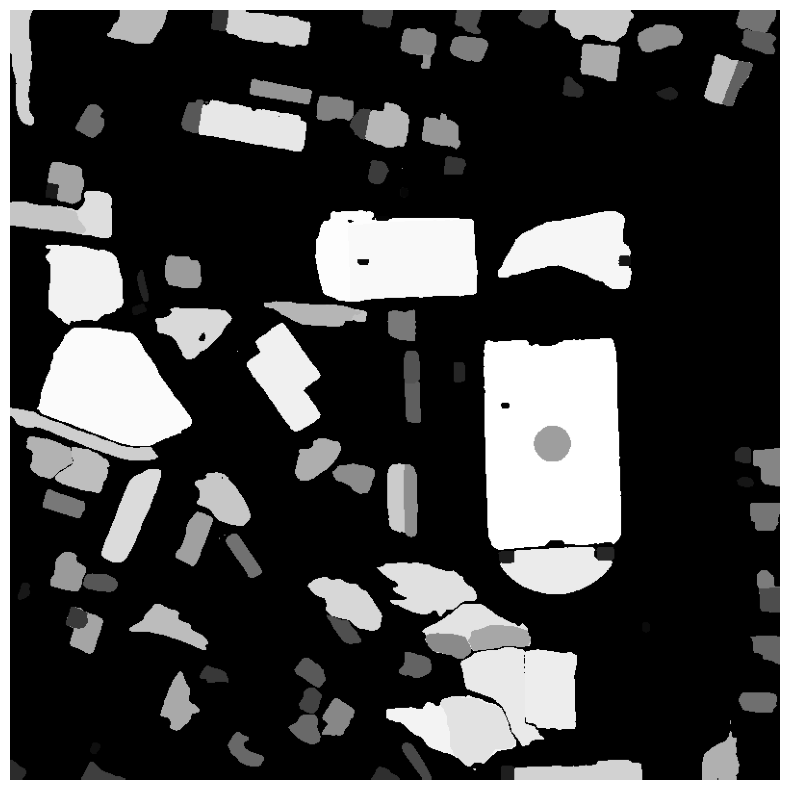

In [8]:
sam.show_masks(cmap="binary_r")

Show the annotations (objects with random color) on the input image. Save it as GeoTiff.

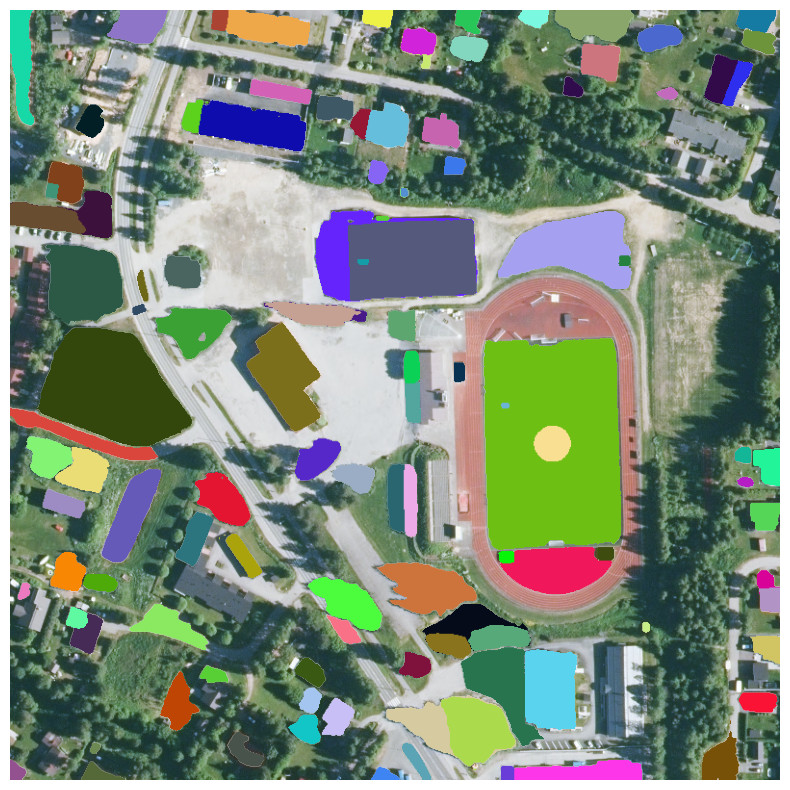

In [9]:
sam.show_anns(axis="off", alpha=1, output=annotated_image)

## Save the results in vector format

The function uses in background `rasterio´s feature-extraction.

In [10]:
sam.tiff_to_gpkg(segmented_image, polygons_file, simplify_tolerance=0.5)

* `simplify_tolerance` - The maximum allowed geometry displacement. The higher this value, the smaller the number of vertices in the resulting geometry. With default value all polygons would have zig-zag edges.

Have a quick look on the created file.

In [11]:
polygons = geopandas.read_file(polygons_file)
polygons.head()

,value,geometry
0,33.0,"POLYGON ((445868.5 7378386, 445868.5 7378379, ..."
1,31.0,"POLYGON ((445951 7378386, 445951 7378385, 4459..."
2,65.0,"POLYGON ((445893 7378376.5, 445892.5 7378376, ..."
3,65.0,"POLYGON ((445900.5 7378376.5, 445900 7378376, ..."
4,23.0,"POLYGON ((445790.5 7378386, 445789.5 7378376, ..."


<Axes: >

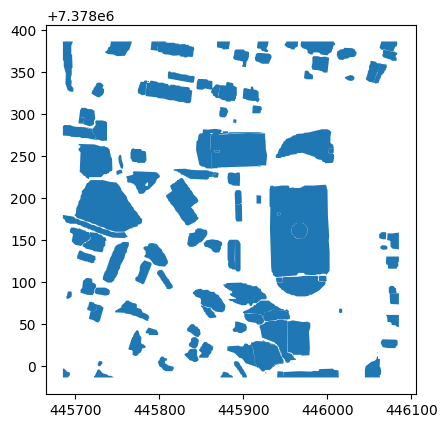

In [12]:
polygons.plot()

This creates for some detected objects several polygons, inc some very small. All polygons belonging to the same object, have the same `value`. So in real usage, some more cleaning is needed. How many detected objects?

In [13]:
polygons['value'].nunique()

113

How many polygons?

In [14]:
polygons.shape[0]

246

## Task

* Try the batch mode.
    * The generation takes even more time, wait.
    * The `show_anns` function gives error, skip it.
    * Note that all polygons get same `value` and how the number of polygons changes
* Try to create segmentation with different image sizes.
* If you want, try also some other area in Finland.